# Hidden Markov Models for Human Activity Recognition
  
**Sensors:** Accelerometer & Gyroscope (Sensor Logger / iPhone & Android)  
**Activities:** Still · Standing · Walking · Jumping

---

This notebook performs the below processes:

1. Load & visualize raw motion data  
2. Preprocess & harmonize sampling rates  
3. Extract time- and frequency-domain features  
4. Train a Gaussian HMM with **Baum–Welch**  
5. Decode activities with the **Viterbi** algorithm  
6. Evaluate on held-out (unseen) windows

In [ ]:
import warnings
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.colors import ListedColormap
from scipy.fft import rfft, rfftfreq
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

# Paths and constants
ROOT = Path(".").resolve()
DATASET_DIR = ROOT / "dataset"
FIGURES_DIR = ROOT / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

ACTIVITIES = ["still", "standing", "walking", "jumping"]
STATE_TO_IDX = {a: i for i, a in enumerate(ACTIVITIES)}
IDX_TO_STATE = {i: a for a, i in STATE_TO_IDX.items()}
N_STATES = len(ACTIVITIES)

TARGET_HZ = 100.0          # harmonized sampling rate (Metadata: 10 ms → 100 Hz)
TRIM_START_SEC = 1.0       # skip phone placement / record-button tap
TRIM_END_SEC = 10.0        # stop before pause-button tap at 11 s
WINDOW_SAMPLES = 100       # 1 s window — captures ~1 gait cycle at walking pace
HOP_SAMPLES = 50           # 50 % overlap - windows per 9 s trimmed segment
RANDOM_SEED = 42

# Plot style
PALETTE = {
    "still": "#4C72B0",
    "standing": "#55A868",
    "walking": "#C44E52",
    "jumping": "#8172B3",
}
sns.set_theme(style="whitegrid", context="notebook", font_scale=1.05)
plt.rcParams.update({"figure.dpi": 110, "figure.figsize": (10, 4)})

sys.path.insert(0, str(ROOT / "scripts"))
from data_utils import (
    UNSEEN_SESSION_PREFIXES,
    extract_windows_from_df,
    find_all_recording_dirs,
    is_unseen_session,
    load_all_windows,
    load_merged_sensors,
    preprocess_recording,
    unzip_archives,
)

np.random.seed(RANDOM_SEED)


## 1 · Data Loading & Exploration

Recordings were collected with **Sensor Logger** on **multiple phones** (iOS and Android) at **100 Hz** (10 ms sample interval). The session table below lists every device per recording.

**Dataset scale:** counts are computed when this notebook runs - see the loaded session summary and device snapshot in the next cells. **Four unseen sessions**  are reserved for evaluation and never used in training.


In [2]:
unzip_archives(DATASET_DIR)
sessions = find_all_recording_dirs(DATASET_DIR)

collection_summary = pd.DataFrame([
    {
        "Activity": s["activity"],
        "Session": s["session"],
        "Device": s["device"],
        "Platform": s["platform"],
        "Recording": s["recording_time"],
        "Sample Rate (Hz)": s["sample_rate_hz"],
        "Split": "unseen" if s["is_unseen"] else "train",
    }
    for s in sessions
])

n_train = collection_summary["Split"].eq("train").sum()
n_unseen = collection_summary["Split"].eq("unseen").sum()
print(
    f"Loaded {len(sessions)} recording sessions "
    f"({n_train} train, {n_unseen} unseen)"
)
print("Unseen test sessions:", ", ".join(UNSEEN_SESSION_PREFIXES))

device_inventory = (
    collection_summary.groupby(["Device", "Platform"], dropna=False)
    .agg(
        Sessions=("Session", "count"),
        Activities=("Activity", lambda s: ", ".join(sorted(s.unique()))),
    )
    .reset_index()
    .sort_values(["Device", "Platform"])
)
print("\nDevices in this dataset snapshot:")
display(device_inventory)
collection_summary


Loaded 87 recording sessions (83 train, 4 unseen)
Unseen test sessions: still5-2026-07-01, standing5-2026-07-01, walking5-2026-07-01, jumping5-2026-07-01

Devices in this dataset snapshot:


,Device,Platform,Sessions,Activities
0,SM-G955U,android,12,"jumping, standing, still, walking"
1,SM-G970U1,android,12,"jumping, standing, still, walking"
2,iPhone 7 Plus,ios,63,"jumping, standing, still, walking"


,Activity,Session,Device,Platform,Recording,Sample Rate (Hz),Split
0,jumping,jumping10-2026-07-04_08-20-13,SM-G970U1,android,2026-07-04_08-20-13,100.0,train
1,jumping,jumping11-2026-07-04_08-24-08,SM-G970U1,android,2026-07-04_08-24-08,100.0,train
2,jumping,jumping6-2026-07-04_08-00-40,SM-G955U,android,2026-07-04_08-00-40,100.0,train
3,jumping,jumping7-2026-07-04_08-02-39,SM-G955U,android,2026-07-04_08-02-39,100.0,train
4,jumping,jumping8-2026-07-04_08-05-33,SM-G955U,android,2026-07-04_08-05-33,100.0,train
...,...,...,...,...,...,...,...
82,walking,walking20-2026-07-04_12-54-57,iPhone 7 Plus,ios,2026-07-04_12-54-57,100.0,train
83,walking,walking21-2026-07-04_12-55-17,iPhone 7 Plus,ios,2026-07-04_12-55-17,100.0,train
84,walking,walking3-2026-06-30_22-33-39,iPhone 7 Plus,ios,2026-06-30_22-33-39,100.0,train
85,walking,walking4-2026-06-30_22-34-38,iPhone 7 Plus,ios,2026-06-30_22-34-38,100.0,train


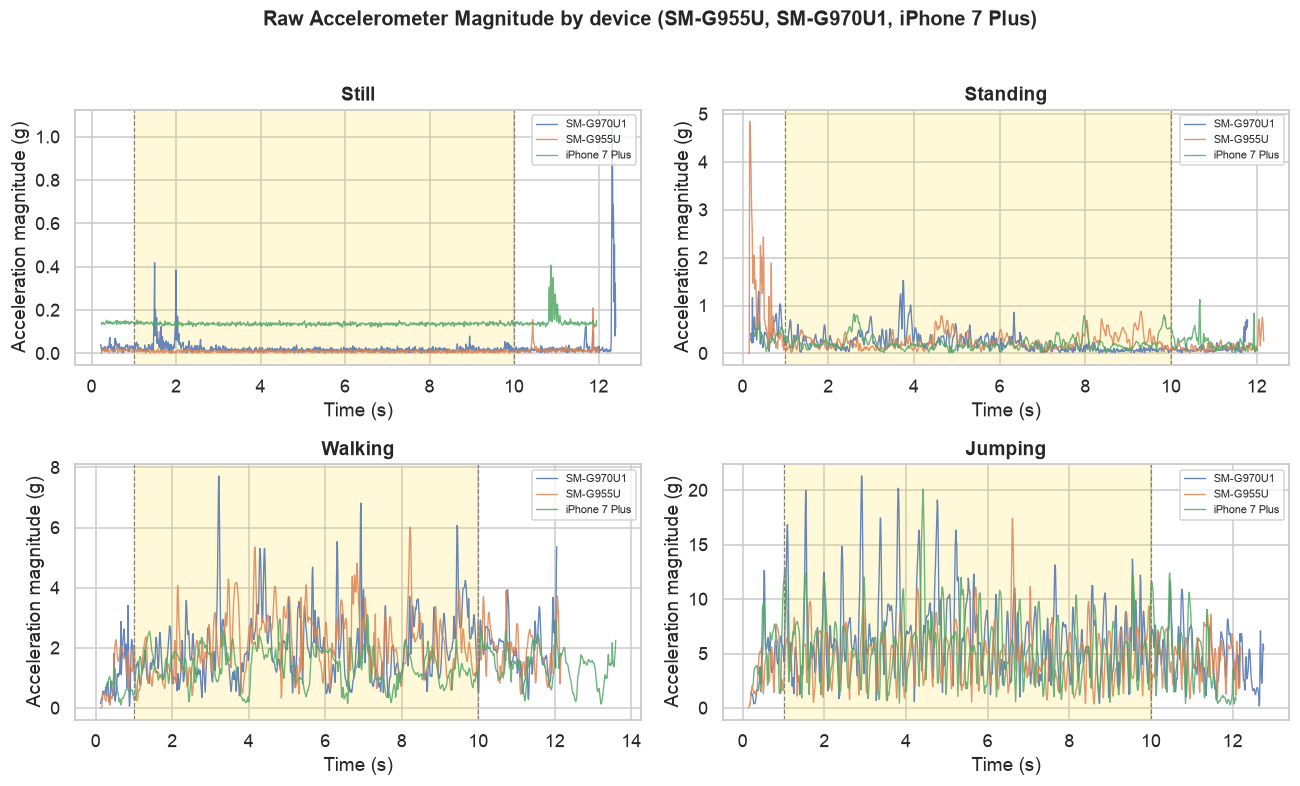

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=False)
axes = axes.ravel()

for ax, activity in zip(axes, ACTIVITIES):
    train_sessions = [
        s for s in sessions if s["activity"] == activity and not s["is_unseen"]
    ]
    devices_seen: set[str] = set()
    for sess in train_sessions:
        if sess["device"] in devices_seen:
            continue
        devices_seen.add(sess["device"])
        df = load_merged_sensors(sess["path"])
        t = df["seconds_elapsed"]
        magnitude = np.sqrt(df["x_accel"] ** 2 + df["y_accel"] ** 2 + df["z_accel"] ** 2)
        ax.plot(t, magnitude, linewidth=0.9, alpha=0.85, label=sess["device"])
    ax.axvspan(TRIM_START_SEC, TRIM_END_SEC, color="gold", alpha=0.15)
    ax.axvline(TRIM_START_SEC, color="gray", linestyle="--", linewidth=0.8)
    ax.axvline(TRIM_END_SEC, color="gray", linestyle="--", linewidth=0.8)
    ax.set_title(activity.capitalize(), fontweight="bold")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Acceleration magnitude (g)")
    ax.legend(fontsize=7, loc="upper right")

devices_used = sorted({s["device"] for s in sessions})
fig.suptitle(
    f"Raw Accelerometer Magnitude by device ({', '.join(devices_used)})",
    fontsize=13,
    fontweight="bold",
    y=1.02,
)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "01_raw_accelerometer.png", bbox_inches="tight")
plt.show()


### Recording protocol & data trimming

Each activity was recorded for approximately 12 s using Sensor Logger, but the **full CSV is not used** for modelling.

| Phase | Approx. time | Problem |
|---|---|---|
| **Start** | 0 – 1 s | Placing the phone and tapping *Record* adds motion spikes |
| **Activity** | 1 – 10 s | Clean segment where the activity is performed steadily |
| **End** | 11 – 12 s | Waiting, then tapping *Pause* introduces another spike |

To match the assignment requirement of **5–10 s of clean activity per recording**, we keep only samples where `seconds_elapsed` is between **`TRIM_START_SEC` (1.0 s)** and **`TRIM_END_SEC` (10.0 s)**. This removes setup and stop interactions. All resampling, windowing, feature extraction, and HMM training use this trimmed segment only.

## 2 · Preprocessing

**Trimming:** Retain only the 1.0 – 10.0 s segment (see above) before any further processing.

**Sampling-rate harmonization:** Recordings come from multiple devices (iOS and Android). Each session is linearly interpolated onto its native grid from metadata, then aligned to **100 Hz** (`TARGET_HZ`) before windowing so features are comparable across phones.

**Windowing logic:** A **1-second window** (100 samples at 100 Hz) captures roughly one walking stride (1–2 Hz) while remaining short enough to track rapid transitions.  
A **50 % hop** (50 samples) yields ~17 overlapping windows per 9 s trimmed segment.

In [4]:
all_windows, window_summary = load_all_windows(DATASET_DIR)

trim_summary = window_summary.groupby("Activity").agg(
    Sessions=("Session", "nunique"),
    Total_Windows=("Windows", "sum"),
)
train_ws = window_summary[window_summary["Split"] == "train"].groupby("Activity")["Windows"].sum()
unseen_ws = window_summary[window_summary["Split"] == "unseen"].groupby("Activity")["Windows"].sum()
trim_summary["Train_Windows"] = train_ws
trim_summary["Unseen_Windows"] = unseen_ws

device_snapshot = (
    window_summary.groupby(["Activity", "Device", "Platform"], dropna=False)
    .agg(
        Sessions=("Session", "nunique"),
        Total_Windows=("Windows", "sum"),
        Avg_Sample_Rate_Hz=("Sample Rate (Hz)", "mean"),
    )
    .reset_index()
    .sort_values(["Activity", "Device"])
)

print("Trimmed segment summary per activity:")
display(trim_summary)
print("\nDataset snapshot by activity and device:")
display(device_snapshot)
print(f"\nTotal windows: {len(all_windows)}")
pd.Series([w["activity"] for w in all_windows]).value_counts().reindex(ACTIVITIES).rename("Windows per activity")


Trimmed segment summary per activity:


,Sessions,Total_Windows,Train_Windows,Unseen_Windows
Activity,,,,
jumping,21,353,337,16
standing,22,359,342,17
still,22,364,348,16
walking,22,364,347,17



Dataset snapshot by activity and device:


,Activity,Device,Platform,Sessions,Total_Windows,Avg_Sample_Rate_Hz
0,jumping,SM-G955U,android,3,51,100.0
1,jumping,SM-G970U1,android,3,50,100.0
2,jumping,iPhone 7 Plus,ios,15,252,100.0
3,standing,SM-G955U,android,3,49,100.0
4,standing,SM-G970U1,android,3,49,100.0
5,standing,iPhone 7 Plus,ios,16,261,100.0
6,still,SM-G955U,android,3,51,100.0
7,still,SM-G970U1,android,3,49,100.0
8,still,iPhone 7 Plus,ios,16,264,100.0
9,walking,SM-G955U,android,3,50,100.0



Total windows: 1440


still       364
standing    359
walking     364
jumping     353
Name: Windows per activity, dtype: int64

## 3 · Feature Extraction

| Feature | Domain | Rationale |
|---|---|---|
| Mean of accel magnitude | Time | Separates static (still/standing) from dynamic activities |
| Variance of accel magnitude | Time | Captures movement intensity (jumping > walking > still) |
| Accel RMS | Time | Robust measure of vibration amplitude during locomotion |
| Signal Magnitude Area (SMA) | Time | Aggregates overall body motion across axes |
| Gyroscope magnitude variance | Time | Distinguishes standing micro-sway from phone-on-desk stillness |
| Correlation (x–y accel) | Time | Reflects orientation / coordination patterns |
| Dominant frequency | Frequency (FFT) | Walking & jumping have distinct rhythmic peaks |
| Spectral energy | Frequency (FFT) | Total periodic power in the 0.5–15 Hz band |
| Walk/jump energy ratio | Frequency (FFT) | Separates walking cadence (0.5–2.5 Hz) from jump impacts (2–5 Hz) |
| Gyroscope magnitude mean | Time | Helps distinguish upright standing sway from desk stillness |
| Accel magnitude std | Time | Captures burstiness of jumping vs steadier walking |

Features are **Z-score normalized** so scales are comparable and Gaussian emission densities are well-conditioned.


In [5]:
FEATURE_NAMES = [
    "accel_mag_mean",
    "accel_mag_var",
    "accel_rms",
    "sma",
    "gyro_mag_var",
    "corr_xy",
    "dominant_freq",
    "spectral_energy",
    "walk_jump_energy_ratio",
    "gyro_mag_mean",
    "accel_mag_std",
]


def _fft_features(signal: np.ndarray, sample_rate: float) -> tuple[float, float]:
    centered = signal - signal.mean()
    spectrum = np.abs(rfft(centered))
    freqs = rfftfreq(len(centered), d=1.0 / sample_rate)
    band = (freqs >= 0.5) & (freqs <= 15.0)
    if not band.any():
        return 0.0, 0.0
    return float(freqs[band][np.argmax(spectrum[band])]), float(np.sum(spectrum[band] ** 2))


def _band_energy(signal: np.ndarray, sample_rate: float, lo: float, hi: float) -> float:
    centered = signal - signal.mean()
    spectrum = np.abs(rfft(centered))
    freqs = rfftfreq(len(centered), d=1.0 / sample_rate)
    mask = (freqs >= lo) & (freqs <= hi)
    return float(np.sum(spectrum[mask] ** 2)) if mask.any() else 0.0


def compute_features(window_df: pd.DataFrame, sample_rate: float = TARGET_HZ) -> np.ndarray:
    """Return an 11-dimensional feature vector for one window."""
    ax, ay, az = window_df["x_accel"], window_df["y_accel"], window_df["z_accel"]
    gx, gy, gz = window_df["x_gyro"], window_df["y_gyro"], window_df["z_gyro"]
    mag = np.sqrt(ax**2 + ay**2 + az**2)
    gyro_mag = np.sqrt(gx**2 + gy**2 + gz**2)

    dominant_freq, spectral_energy = _fft_features(mag.values, sample_rate)
    walk_energy = _band_energy(mag.values, sample_rate, 0.5, 2.5)
    jump_energy = _band_energy(mag.values, sample_rate, 2.0, 5.0)

    return np.array([
        mag.mean(), mag.var(), np.sqrt((mag**2).mean()),
        (np.abs(ax).sum() + np.abs(ay).sum() + np.abs(az).sum()) / len(mag),
        gyro_mag.var(),
        np.corrcoef(ax, ay)[0, 1] if mag.var() > 0 else 0.0,
        dominant_freq, spectral_energy,
        walk_energy / (jump_energy + 1e-9),
        gyro_mag.mean(), mag.std(),
    ])


X_list, y_list, meta_list = [], [], []
for i, w in enumerate(all_windows):
    X_list.append(compute_features(w["data"]))
    y_list.append(STATE_TO_IDX[w["activity"]])
    meta_list.append({
        "idx": i,
        "activity": w["activity"],
        "session": w["session"],
        "start_s": w["start_s"],
        "is_unseen": is_unseen_session(w["session"]),
    })

X_raw = np.vstack(X_list)
y = np.array(y_list)
meta_df = pd.DataFrame(meta_list)

train_mask = ~meta_df["is_unseen"].values
test_mask = meta_df["is_unseen"].values

scaler = StandardScaler()
X_scaled = np.zeros_like(X_raw)
X_scaled[train_mask] = scaler.fit_transform(X_raw[train_mask])
X_scaled[test_mask] = scaler.transform(X_raw[test_mask])

X_train, y_train = X_scaled[train_mask], y[train_mask]
X_test, y_test = X_scaled[test_mask], y[test_mask]

feature_preview = pd.DataFrame(X_scaled[train_mask], columns=FEATURE_NAMES)
feature_preview["activity"] = [IDX_TO_STATE[label] for label in y[train_mask]]
feature_preview.groupby("activity")[FEATURE_NAMES].mean().round(3)


,accel_mag_mean,accel_mag_var,accel_rms,sma,gyro_mag_var,corr_xy,dominant_freq,spectral_energy,walk_jump_energy_ratio,gyro_mag_mean,accel_mag_std
activity,,,,,,,,,,,
jumping,1.361,0.708,1.352,1.333,0.636,-0.104,0.160,0.717,-0.234,1.206,1.308
standing,-0.527,-0.236,-0.518,-0.521,-0.333,0.407,-0.410,-0.239,0.056,-0.620,-0.481
still,-0.555,-0.236,-0.547,-0.555,-0.362,-0.064,0.787,-0.239,-0.094,-0.754,-0.516
walking,-0.246,-0.218,-0.253,-0.225,0.074,-0.236,-0.540,-0.221,0.266,0.195,-0.279


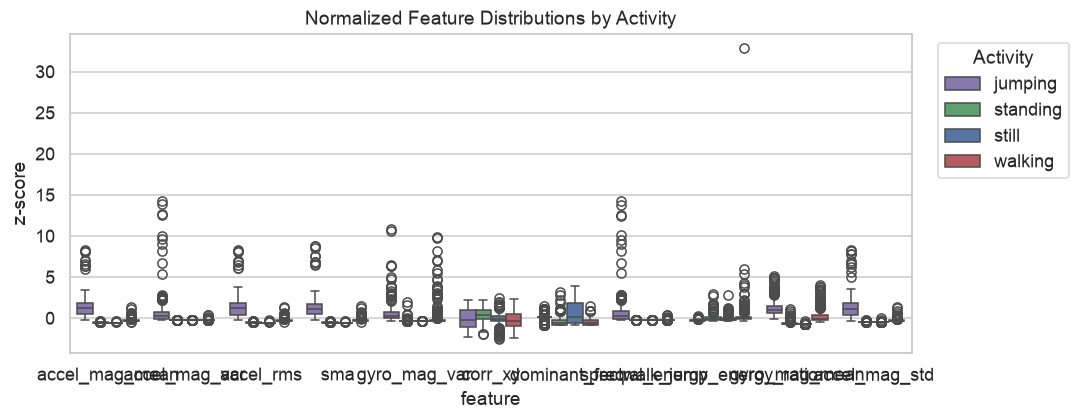

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
plot_df = feature_preview.melt(id_vars="activity", var_name="feature", value_name="z-score")
sns.boxplot(data=plot_df, x="feature", y="z-score", hue="activity", palette=PALETTE, ax=ax)
ax.set_title("Normalized Feature Distributions by Activity")
ax.legend(title="Activity", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "02_feature_distributions.png", bbox_inches="tight")
plt.show()

## 4 · Gaussian Hidden Markov Model

| Component | Symbol | Description |
|---|---|---|
| Hidden states | \(Z\) | `{still, standing, walking, jumping}` |
| Observations | \(X\) | 11-D normalized feature vectors |
| Transition matrix | \(A\) | \(P(Z_{t+1} \mid Z_t)\) |
| Emissions | \(B\) | \(\mathcal{N}(\mu_j, \Sigma_j)\) per state |
| Initial probs | \(\pi\) | \(P(Z_1)\) |

Implementation of **Baum–Welch** for training and the **Viterbi** algorithm for decoding.

In [7]:
class GaussianHMM:
    """Discrete-state HMM with diagonal-covariance Gaussian emissions."""

    def __init__(
        self,
        n_states: int,
        n_features: int,
        tol: float = 1e-4,
        max_iter: int = 200,
        self_transition: float = 0.95,
    ):
        self.n_states = n_states
        self.n_features = n_features
        self.tol = tol
        self.max_iter = max_iter
        self.self_transition = self_transition
        off = (1.0 - self_transition) / max(n_states - 1, 1)
        self.A = np.full((n_states, n_states), off)
        np.fill_diagonal(self.A, self_transition)
        self.pi = np.full(n_states, 1.0 / n_states)
        self.means = np.random.randn(n_states, n_features) * 0.1
        self.vars = np.ones((n_states, n_features))
        self.log_likelihoods_: list[float] = []

    def _log_emission(self, X: np.ndarray) -> np.ndarray:
        T = len(X)
        log_B = np.zeros((T, self.n_states))
        const = self.n_features * np.log(2 * np.pi)
        for j in range(self.n_states):
            var = np.maximum(self.vars[j], 1e-6)
            diff = X - self.means[j]
            log_B[:, j] = -0.5 * (const + np.sum(np.log(var)) + np.sum(diff**2 / var, axis=1))
        return log_B

    def _forward_backward(self, X: np.ndarray):
        log_B = self._log_emission(X)
        T, N = len(X), self.n_states
        log_pi = np.log(self.pi + 1e-300)
        log_A = np.log(self.A + 1e-300)

        log_alpha = np.zeros((T, N))
        log_alpha[0] = log_pi + log_B[0]
        for t in range(1, T):
            for j in range(N):
                log_alpha[t, j] = log_B[t, j] + _logsumexp(log_alpha[t - 1] + log_A[:, j])

        log_likelihood = _logsumexp(log_alpha[-1])

        log_beta = np.zeros((T, N))
        for t in range(T - 2, -1, -1):
            for i in range(N):
                log_beta[t, i] = _logsumexp(log_A[i] + log_B[t + 1] + log_beta[t + 1])

        log_gamma = log_alpha + log_beta
        log_gamma -= _logsumexp(log_gamma, axis=1, keepdims=True)
        gamma = np.exp(log_gamma)

        xi = np.zeros((T - 1, N, N))
        for t in range(T - 1):
            for i in range(N):
                for j in range(N):
                    xi[t, i, j] = np.exp(
                        log_alpha[t, i] + log_A[i, j] + log_B[t + 1, j] + log_beta[t + 1, j] - log_likelihood
                    )
        return gamma, xi, log_likelihood

    def fit(self, sequences: list[np.ndarray], freeze_emissions: bool = True) -> "GaussianHMM":
        """Baum–Welch EM; optionally freeze supervised emission parameters."""
        saved_means = self.means.copy()
        saved_vars = self.vars.copy()
        saved_pi = self.pi.copy()
        prev_ll = -np.inf

        for iteration in range(self.max_iter):
            pi_acc = np.zeros(self.n_states)
            A_num = np.zeros((self.n_states, self.n_states))
            A_den = np.zeros(self.n_states)
            mean_num = np.zeros((self.n_states, self.n_features))
            var_num = np.zeros((self.n_states, self.n_features))
            var_den = np.zeros(self.n_states)
            total_ll = 0.0

            for X in sequences:
                gamma, xi, ll = self._forward_backward(X)
                total_ll += ll
                pi_acc += gamma[0]
                A_num += xi.sum(axis=0)
                A_den += gamma[:-1].sum(axis=0)
                if not freeze_emissions:
                    for j in range(self.n_states):
                        mean_num[j] += gamma[:, j] @ X
                        var_num[j] += gamma[:, j] @ (X - self.means[j]) ** 2
                        var_den[j] += gamma[:, j].sum()

            self.pi = pi_acc / pi_acc.sum()
            self.A = A_num / (A_den[:, None] + 1e-300)
            if not freeze_emissions:
                for j in range(self.n_states):
                    self.means[j] = mean_num[j] / (var_den[j] + 1e-300)
                    self.vars[j] = var_num[j] / (var_den[j] + 1e-300) + 1e-3

            if freeze_emissions:
                self.means, self.vars = saved_means, saved_vars

            self.log_likelihoods_.append(total_ll)
            if abs(total_ll - prev_ll) < self.tol:
                print(f"Baum–Welch converged at iteration {iteration + 1}  (log-lik Δ < {self.tol})")
                break
            prev_ll = total_ll
        else:
            print(f"Baum–Welch stopped after {self.max_iter} iterations")
        return self

    def predict(self, X: np.ndarray) -> np.ndarray:
        log_B = self._log_emission(X)
        T, N = len(X), self.n_states
        log_delta = np.zeros((T, N))
        psi = np.zeros((T, N), dtype=int)
        log_pi = np.log(self.pi + 1e-300)
        log_A = np.log(self.A + 1e-300)

        log_delta[0] = log_pi + log_B[0]
        for t in range(1, T):
            for j in range(N):
                scores = log_delta[t - 1] + log_A[:, j]
                psi[t, j] = np.argmax(scores)
                log_delta[t, j] = scores[psi[t, j]] + log_B[t, j]

        path = np.zeros(T, dtype=int)
        path[-1] = np.argmax(log_delta[-1])
        for t in range(T - 2, -1, -1):
            path[t] = psi[t + 1, path[t + 1]]
        return path

    def initialize_from_labels(self, X: np.ndarray, labels: np.ndarray) -> None:
        for j in range(self.n_states):
            mask = labels == j
            if mask.any():
                self.means[j] = X[mask].mean(axis=0)
                self.vars[j] = X[mask].var(axis=0) + 1e-3
        counts = np.bincount(labels, minlength=self.n_states).astype(float)
        self.pi = counts / counts.sum()


def _logsumexp(a, axis=None, keepdims=False):
    a_max = np.max(a, axis=axis, keepdims=True)
    out = a_max + np.log(np.sum(np.exp(a - a_max), axis=axis, keepdims=True))
    return out if keepdims else np.squeeze(out, axis=axis)


## 5 · Training

Emission parameters are **warm-started** from labelled training windows. **Baum–Welch** then refines the transition matrix on **real single-activity recording sessions** (each session is one steady activity), which matches how the data were collected. After EM, supervised emission parameters are restored so multi-device Baum–Welch refines transitions without distorting class signatures. The transition matrix is then row-normalized with a minimum self-transition of 0.95 per state.


In [8]:
print(f"Training windows: {len(X_train)}  |  Unseen test windows: {len(X_test)}")


def build_session_sequences(X_data: np.ndarray, meta_train: pd.DataFrame) -> list[np.ndarray]:
    """One time-ordered sequence per recording session (single activity each)."""
    sequences = []
    for _, group in meta_train.groupby("session", sort=True):
        order = group.sort_values("start_s").index.to_numpy()
        sequences.append(X_data[order])
    return sequences


def reinforce_transition_diagonal(A: np.ndarray, min_self: float = 0.95) -> np.ndarray:
    """Keep Baum–Welch transitions but discourage spurious cross-activity jumps."""
    A = A.copy()
    for i in range(A.shape[0]):
        A[i, i] = max(A[i, i], min_self)
        A[i] /= A[i].sum()
    return A


train_meta = meta_df.loc[train_mask].copy()
train_sequences = build_session_sequences(X_scaled, train_meta)

hmm = GaussianHMM(n_states=N_STATES, n_features=X_scaled.shape[1], tol=1e-3, max_iter=50)
hmm.initialize_from_labels(X_train, y_train)
saved_means, saved_vars, saved_pi = hmm.means.copy(), hmm.vars.copy(), hmm.pi.copy()
hmm.fit(train_sequences, freeze_emissions=False)
hmm.means, hmm.vars, hmm.pi = saved_means, saved_vars, saved_pi
hmm.A = reinforce_transition_diagonal(hmm.A)


Training windows: 1374  |  Unseen test windows: 66
Baum–Welch converged at iteration 44  (log-lik Δ < 0.001)


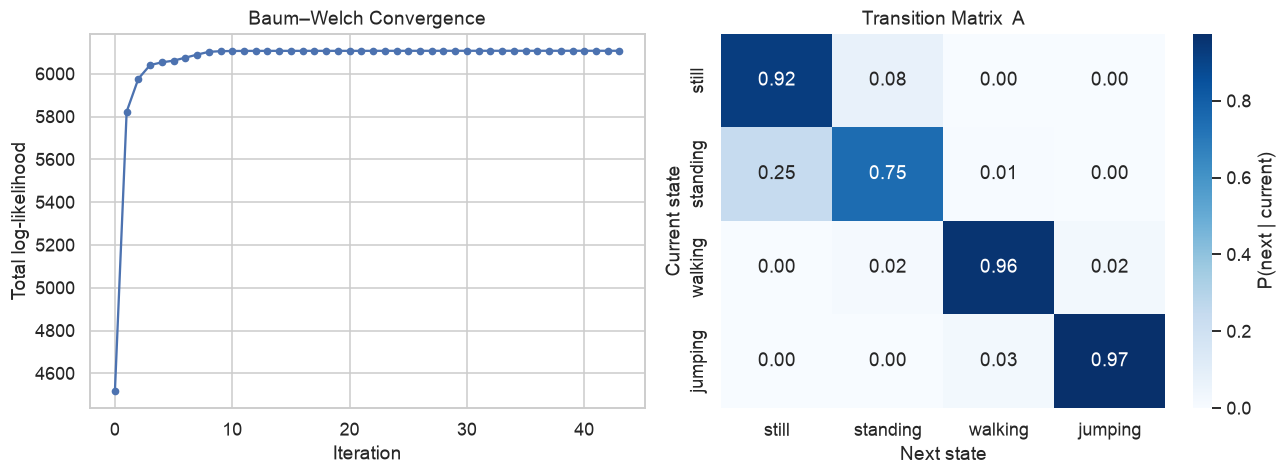

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Convergence
axes[0].plot(hmm.log_likelihoods_, marker="o", markersize=4, color="#4C72B0")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Total log-likelihood")
axes[0].set_title("Baum–Welch Convergence")

# Transition matrix heatmap
A_df = pd.DataFrame(hmm.A, index=ACTIVITIES, columns=ACTIVITIES)
sns.heatmap(A_df, annot=True, fmt=".2f", cmap="Blues", ax=axes[1], cbar_kws={"label": "P(next | current)"})
axes[1].set_title("Transition Matrix  A")
axes[1].set_xlabel("Next state")
axes[1].set_ylabel("Current state")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "03_transition_matrix.png", bbox_inches="tight")
plt.show()

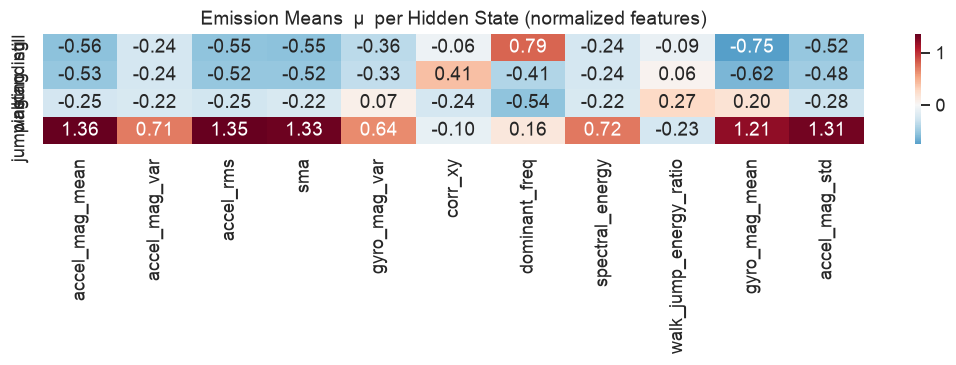

In [10]:
# Emission means heatmap
emission_df = pd.DataFrame(hmm.means, index=ACTIVITIES, columns=FEATURE_NAMES)
fig, ax = plt.subplots(figsize=(10, 3.5))
sns.heatmap(emission_df, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax)
ax.set_title("Emission Means  μ  per Hidden State (normalized features)")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "04_emission_means.png", bbox_inches="tight")
plt.show()

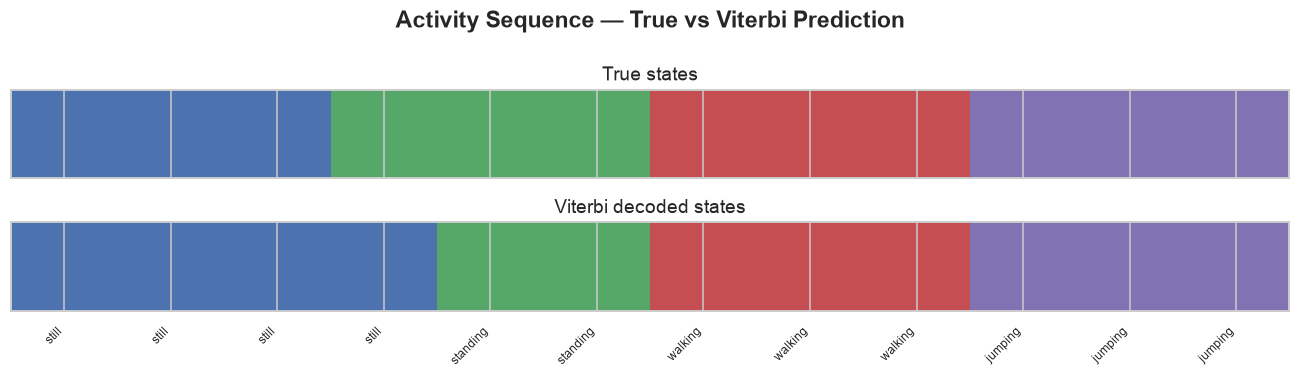

In [11]:
test_sequence = np.vstack([
    X_test[y_test == s][:3] for s in range(N_STATES) if (y_test == s).any()
])
true_states = np.concatenate([
    np.full(min(3, (y_test == s).sum()), s) for s in range(N_STATES) if (y_test == s).any()
])
decoded = hmm.predict(test_sequence)

state_cmap = ListedColormap([PALETTE[IDX_TO_STATE[i]] for i in range(N_STATES)])

fig, axes = plt.subplots(2, 1, figsize=(12, 3.5), sharex=True, gridspec_kw={"height_ratios": [1, 1]})
for ax, states, title in zip(axes, [true_states, decoded], ["True states", "Viterbi decoded states"]):
    ax.imshow(states.reshape(1, -1), aspect="auto", cmap=state_cmap, vmin=0, vmax=N_STATES - 1)
    ax.set_yticks([])
    ax.set_title(title)
    ax.set_xticks(range(len(states)))
    ax.set_xticklabels([IDX_TO_STATE[s] for s in states], rotation=45, ha="right", fontsize=8)

fig.suptitle("Activity Sequence — True vs Viterbi Prediction", fontweight="bold")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "05_decoded_sequence.png", bbox_inches="tight")
plt.show()

## 6 · Evaluation on Unseen Data

**Decoding:** Each unseen session is decoded end-to-end with **Viterbi** over its time-ordered windows (not independent per-window emission argmax).

Metrics per activity:
- **Sensitivity** = TP / (TP + FN)
- **Specificity** = TN / (TN + FP)
- **Accuracy** = (TP + TN) / total one-vs-rest


In [12]:
def per_class_metrics(y_true: np.ndarray, y_pred: np.ndarray, n_classes: int) -> pd.DataFrame:
    rows = []
    for c in range(n_classes):
        tp = np.sum((y_true == c) & (y_pred == c))
        fn = np.sum((y_true == c) & (y_pred != c))
        fp = np.sum((y_true != c) & (y_pred == c))
        tn = np.sum((y_true != c) & (y_pred != c))
        sensitivity = tp / (tp + fn) if (tp + fn) else 0.0
        specificity = tn / (tn + fp) if (tn + fp) else 0.0
        accuracy = (tp + tn) / len(y_true)
        rows.append({
            "State (Activity)": IDX_TO_STATE[c],
            "Number of Samples": int((y_true == c).sum()),
            "Sensitivity": round(sensitivity, 3),
            "Specificity": round(specificity, 3),
            "Overall Accuracy": round(accuracy, 3),
        })
    return pd.DataFrame(rows)


def predict_test_labels_viterbi(
    model: GaussianHMM,
    X: np.ndarray,
    meta: pd.DataFrame,
    test_mask: np.ndarray,
) -> np.ndarray:
    """Decode each unseen session with Viterbi (windows sorted by start_s)."""
    test_positions = np.where(test_mask)[0]
    test_meta = meta.iloc[test_positions].copy()
    test_meta["test_idx"] = np.arange(len(test_positions))

    y_pred = np.zeros(len(test_positions), dtype=int)
    for _, group in test_meta.groupby("session", sort=False):
        group = group.sort_values("start_s")
        session_idx = group.index.to_numpy()
        y_pred[group["test_idx"].to_numpy()] = model.predict(X[session_idx])
    return y_pred


y_pred_test = predict_test_labels_viterbi(hmm, X_scaled, meta_df, test_mask)
results_table = per_class_metrics(y_test, y_pred_test, N_STATES)
overall_acc = (y_pred_test == y_test).mean()
print(f"Overall window accuracy on unseen sessions: {overall_acc:.1%}\n")
results_table


Overall window accuracy on unseen sessions: 83.3%



,State (Activity),Number of Samples,Sensitivity,Specificity,Overall Accuracy
0,still,16,1.000,0.820,0.864
1,standing,17,0.471,1.000,0.864
2,walking,17,1.000,0.959,0.970
3,jumping,16,0.875,1.000,0.970


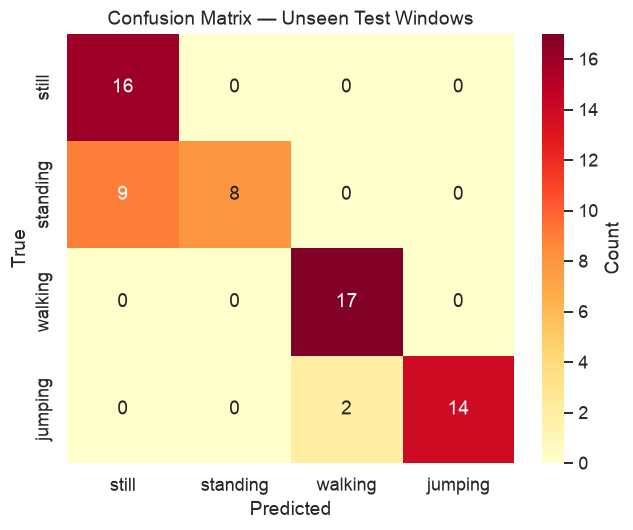

In [13]:
cm = confusion_matrix(y_test, y_pred_test, labels=list(range(N_STATES)))
cm_df = pd.DataFrame(cm, index=ACTIVITIES, columns=ACTIVITIES)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="YlOrRd", ax=ax, cbar_kws={"label": "Count"})
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion Matrix — Unseen Test Windows")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "06_confusion_matrix.png", bbox_inches="tight")
plt.show()

In [14]:
import runpy

runpy.run_path(str(ROOT / "scripts" / "prepare_dataset.py"), run_name="__main__")

Exported 87 trimmed recordings to /Users/avellin/Desktop/Campus/Formative2-Hidden_Markov_Models/dataset/cleaned
Exported 1440 labelled window CSVs to /Users/avellin/Desktop/Campus/Formative2-Hidden_Markov_Models/dataset/windows
activity
jumping     21
standing    22
still       22
walking     22
Name: sessions, dtype: int64
activity
jumping     353
standing    359
still       364
walking     364
Name: windows, dtype: int64


{'__name__': '__main__',
 '__doc__': 'Export labeled, windowed CSV files from all Sensor Logger recordings.',
 '__package__': '',
 '__loader__': None,
 '__spec__': None,
 '__file__': '/Users/avellin/Desktop/Campus/Formative2-Hidden_Markov_Models/scripts/prepare_dataset.py',
 '__cached__': None,
 '__builtins__': {'__name__': 'builtins',
  '__doc__': "Built-in functions, types, exceptions, and other objects.\n\nThis module provides direct access to all 'built-in'\nidentifiers of Python; for example, builtins.len is\nthe full name for the built-in function len().\n\nThis module is not normally accessed explicitly by most\napplications, but can be useful in modules that provide\nobjects with the same name as a built-in value, but in\nwhich the built-in of that name is also needed.",
  '__package__': '',
  '__loader__': _frozen_importlib.BuiltinImporter,
  '__spec__': ModuleSpec(name='builtins', loader=<class '_frozen_importlib.BuiltinImporter'>, origin='built-in'),
  '__build_class__': <fu